# Conceitos de Probabilidade e Sinais Aleatórios em Sistemas de Comunicações

## Probabilidade e sinais aleatórios em comunicações?

Em sistemas de comunicações, diversos fenômenos não podem ser descritos apenas por sinais determinísticos. Entre eles:

- o **ruído térmico** em receptores;
- a **interferência** entre usuários;
- as **flutuações do canal**;
- as **incertezas na detecção de símbolos**;
- o comportamento estatístico de mensagens e fontes de informação.

## Conceitos de Probabilidade


### Variáveis aleatórias

É uma função que associa um valor numérico a cada resultado de um experimento aleatório.

* **Variável Aleatória Discreta**:
  Assume um conjunto **finito ou enumerável** de valores.

É representada por sua **função de probabilidade** (PMF – *Probability Mass Function*):

$$
P(X = x_i) = p(x_i)
$$
com as propriedades:
$$
p(x_i) \geq 0 \quad \text{e} \quad \sum_i p(x_i) = 1
$$

Fornece a probabilidade de cada valor possível.

#### Exemplos:
1. Número de bits em erro em um bloco de transmissão digital: $ X \in \{0, 1, 2, ..., n\}$
2. Resultado de um dado: $X \in \{1,2,3,4,5,6\}$


* **Variável Aleatória Contínua**:
  Pode assumir **qualquer valor em um intervalo contínuo** dos números reais.
  

É representada por sua **função densidade de probabilidade** (PDF – *Probability Density Function*):

$$
f_X(x)
$$

com as propriedades:

$$
f_X(x) \geq 0 \quad \text{e} \quad \int_{-\infty}^{\infty} f_X(x)dx = 1
$$

A probabilidade é obtida por integração:

$$
P(a \leq X \leq b) = \int_a^b f_X(x)dx
$$

Obs.:
$$
P(X = x) = 0
$$
para variáveis contínuas.

Exemplos:

1. Ruído térmico em um canal de comunicação:

* Modelado como uma variável aleatória Gaussiana
$$ X \sim \mathcal{N}(\mu, \sigma^2) $$

2.  Amplitude de um sinal analógico recebido

#### Distribuições importantes em comunicações
- Bernoulli e Binomial.
- Uniforme.
- Exponencial.
- Gaussiana (Normal).
- Rayleigh e Rice.
- Poisson.

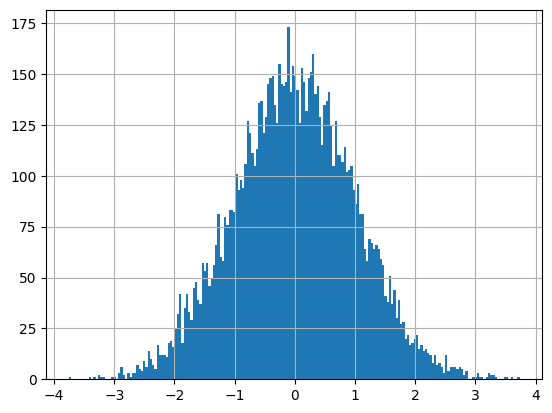

In [3]:
## Adaptado de https://www.geeksforgeeks.org/random-gauss-function-in-python/

# import the required libraries  
import numpy as np
import random  
import matplotlib.pyplot as plt  

SNR_dB = 0

# store the random numbers in a list  
nums = []  
mu = 0
sigma = np.sqrt(pow(10,-SNR_dB/10))

for i in range(10000):  
    temp = random.gauss(mu, sigma)  
    nums.append(temp)  

# plotting a graph  
plt.hist(nums, bins = 200)  
plt.grid()
plt.show()

##  Sinais aleatórios

Um **processo aleatório** é uma família de variáveis aleatórias indexadas por um parâmetro, geralmente o tempo:

$$
X(t), \quad t \in T
$$
para cada instante $t$, $X(t)$ é uma variável aleatória.

Um processo aleatório é um **conjunto de possíveis sinais (ou realizações)**, onde cada sinal representa uma evolução temporal possível do fenômeno.

Podemos pensar de duas formas:
* **Fixando o tempo $t$**: temos uma variável aleatória $ X(t)$
* **Fixando uma realização $\omega$**: temos um sinal no tempo $x(t)$


### Representação

Um processo aleatório pode ser descrito como:
$
X(t, \omega)
$
sendo:
* $t$: tempo
* $\omega$: resultado do experimento aleatório

Normlamente usamos apenas $X(t)$, assumindo implicitamente essa dependência.


### Exemplos

#### Ruído AWGN (Additive White Gaussian Noise)

Para cada instante $t$, $X(t)$ é uma variável aleatória Gaussiana, e ao longo do tempo, gera um sinal ruidoso, de outra forma, cada realização corresponde a um “traço” diferente de ruído.

#### Sinal recebido em um canal com ruído

$
r(t) = s(t) + n(t)
$
* $s(t)$: sinal transmitido (determinístico)
* $n(t)$: processo aleatório (ruído)
* $r(t)$: também é um processo aleatório

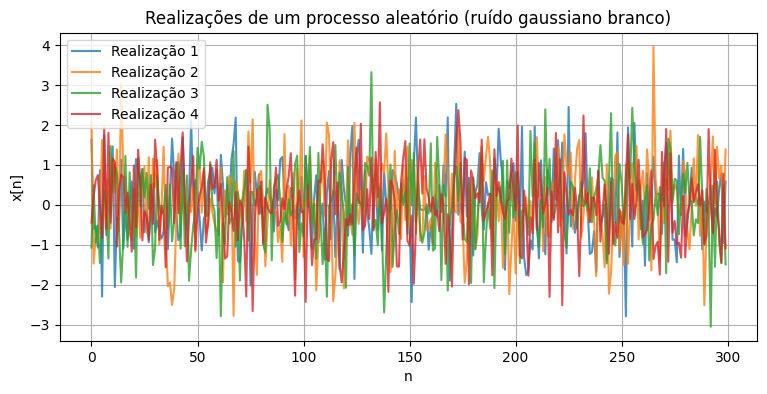

In [7]:
np.random.seed(1)
N = 300
n = np.arange(N)

plt.figure(figsize=(9,4))
for k in range(4):
    x = np.random.normal(0, 1, N)
    plt.plot(n, x, alpha=0.8, label=f'Realização {k+1}')

plt.title('Realizações de um processo aleatório (ruído gaussiano branco)')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid(True)
plt.legend()
plt.show()

Cada curva é uma **realização** diferente do mesmo processo aleatório. Embora todas tenham propriedades estatísticas parecidas, suas formas de onda instantâneas são diferentes.

### Média e autocorrelação
- Função média:

$$
m_X(t) = \mathbb{E}[X(t)]
$$

- Função de autocorrelação:

$$
R_X(t_1,t_2) = \mathbb{E}[X(t_1)X(t_2)]
$$

Essas funções ajudam a caracterizar sinais aleatórios e ruídos.

### Estacionariedade
- Processo estritamente estacionário.
- Processo estacionário em sentido amplo (WSS).
- Dependência da autocorrelação apenas da defasagem $	au$:

$$
R_X(	au)
$$

### Ergodicidade
- Relação entre médias temporais e médias de ensemble.
- Importância prática: muitas vezes temos apenas uma realização medida do sinal.

### Densidade espectral de potência
Para processos WSS, a densidade espectral de potência é obtida pela transformada de Fourier da autocorrelação:

$$
S_X(f) = \mathcal{F}\{R_X(	au)\}
$$

## Média, autocorrelação e interpretação física

Em sinais aleatórios, duas quantidades muito importantes são:

### Média
A média descreve o nível médio do processo:

$$
m_X(t)=\mathbb{E}[X(t)]
$$

Se o ruído tem média nula, então não existe tendência positiva nem negativa.

### Autocorrelação
A autocorrelação mede o quanto o sinal em um instante se relaciona com ele mesmo em outro instante:

$$
R_X(	au)=\mathbb{E}[X(t)X(t+	au)]
$$

- Para ruído branco ideal, a autocorrelação é concentrada em $	au=0$.
- Para sinais filtrados, existe correlação entre amostras vizinhas.

## Exemplo: estimativa da autocorrelação

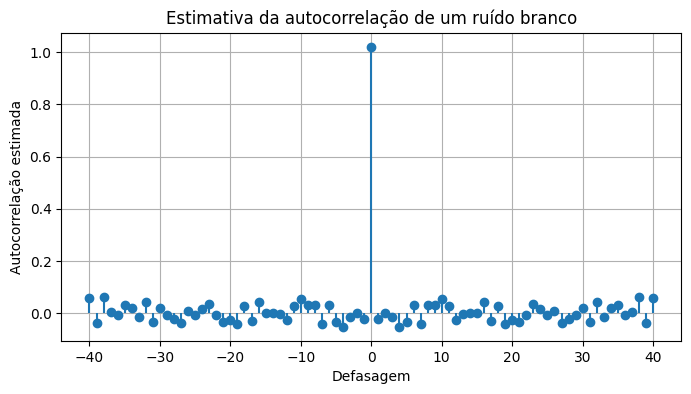

In [9]:
np.random.seed(3)
N = 1024
x = np.random.normal(0, 1, N)

r = np.correlate(x, x, mode='full') / N
lags = np.arange(-N+1, N)

centro = len(r)//2
janela = 40

plt.figure(figsize=(8,4))
plt.stem(lags[centro-janela:centro+janela+1], r[centro-janela:centro+janela+1], basefmt=" ")
plt.title('Estimativa da autocorrelação de um ruído branco')
plt.xlabel('Defasagem')
plt.ylabel('Autocorrelação estimada')
plt.grid(True)
plt.show()

### Interpretação
Observa-se um pico dominante em defasagem zero, coerente com a ideia de ruído branco: fora do ponto central, a correlação tende a ser pequena.

### **Porque usar a autocorrelação**

Conside o sinal $x(t) = Acos(\omega_1 t + \theta)$, sendo $\theta$ uma variável aleatória com distribuição Uniforme entre 0 e $2\pi$.

O sinal $x(t)$ é um processo estocástico, pois cada uma de suas realizações pode ser diferente da anterior, devido a aleatoriedade de fase $\theta.$

Como exemplo, cada execução do código abaixo considerando a curva em azul como referência (fase zero) irá resultar em uma curva pontilhada com fases distinta.

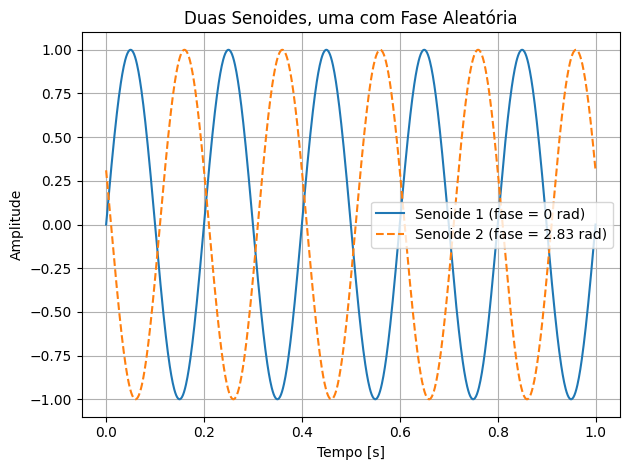

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal
frequencia = 5  # Hz
amplitude = 1
tempo = np.linspace(0, 1, 1000)  # 1 segundo com 1000 amostras

# Geração da fase aleatória
fase1 = np.random.uniform(0, 2 * np.pi)

# Geração das senoides
senoide1 = amplitude * np.sin(2 * np.pi * frequencia * tempo)
senoide2 = amplitude * np.sin(2 * np.pi * frequencia * tempo + fase1)

# Plotagem
plt.plot(tempo, senoide1, label=f'Senoide 1 (fase = 0 rad)')
plt.plot(tempo, senoide2, label=f'Senoide 2 (fase = {fase1:.2f} rad)', linestyle='--')
plt.title('Duas Senoides, uma com Fase Aleatória')
plt.xlabel('Tempo [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Sendo assim, não podemos calcular a Transformada de Fourier de $x(t)$, pois não teremos como afirmar par qual realização (valor de $\theta$) está sendo feito o cálculo.

Neste caso e outros similares, para analisar as componentes de frequência do sinal necessitamos de uma representação média de todas as realizações, e para tanto vamos calcular a autocorrelação de $x(t)$:

$R_{xx}(t_1, t_2) = E[x(t_1,t_2)] = E[Acos(\omega_1 t_1 + θ)Acos(\omega_1 t_2 + θ)]$

$R_{xx}(t_1,t_2) = \frac{A^2}{2}E\{cos[\omega_1 (t_1 - t_2)] + cos[\omega_1 (t_1 + t_2)  + 2θ]\}$

$R_{xx}(t_1,t_2) = \frac{A^2}{2}E\{cos[\omega_1 (t_1 - t_2)]\} + \frac{A^2}{2}E\{cos[\omega_1 (t_1 + t_2)  + 2θ]\}$

Porém $\frac{A^2}{2}E\{cos[\omega_1 (t_1 + t_2)  + 2θ]\} = \frac{A^2}{2}\int_{0}^{2\pi}cos[\omega_1 (t_1 + t_2)  + 2θ]p_\Theta(\theta)d\theta = \frac{A^2}{4\pi}[\sin(\omega_1 (t_1 + t_2) + 2\pi) - sin(\omega(t_1+t_2)] = 0,$ logo

$R_{xx}(t_1,t_2) = \frac{A^2}{2}E\{cos[\omega_1 (t_1 - t_2)]\}$ e escrevendo $\tau = t_1 - t_2$ temos

$R_{xx}(\tau) = \frac{A^2}{2}cos(\omega_1\tau)$ que é uma função determinística.

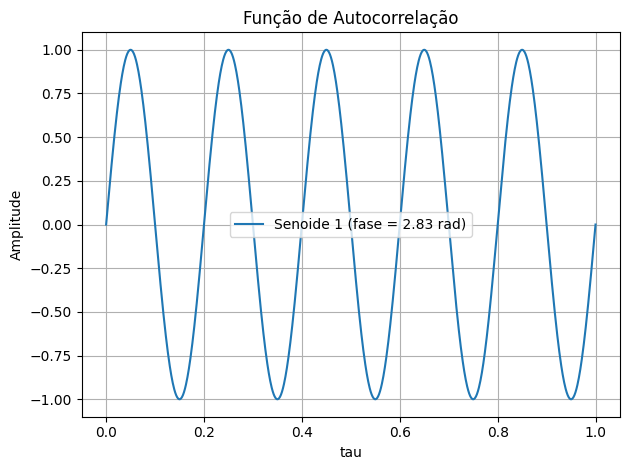

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal
frequencia = 5  # Hz
amplitude = 1
tau = np.linspace(0, 1, 1000)  # 1 segundo com 1000 amostras

# Geração das senoides
senoide1 = amplitude * np.sin(2 * np.pi * frequencia * tau)


# Plotagem
plt.plot(tempo, senoide1, label=f'Senoide 1 (fase = {fase1:.2f} rad)')
plt.title('Função de Autocorrelação')
plt.xlabel('tau')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Densidade espectral de potência (PSD)

A PSD mostra como a potência média de um sinal aleatório está distribuída em frequência. Em comunicações, isso é essencial para:

- analisar banda ocupada;
- modelar ruído;
- projetar filtros;
- estimar interferência.

Para um processo WSS:

$$
S_X(f)=\mathcal{F}\{R_X(\tau)\}
$$

No caso ideal de ruído branco, a PSD é constante em frequência dentro do modelo teórico.

## Exemplo 5: estimativa espectral de um ruído branco

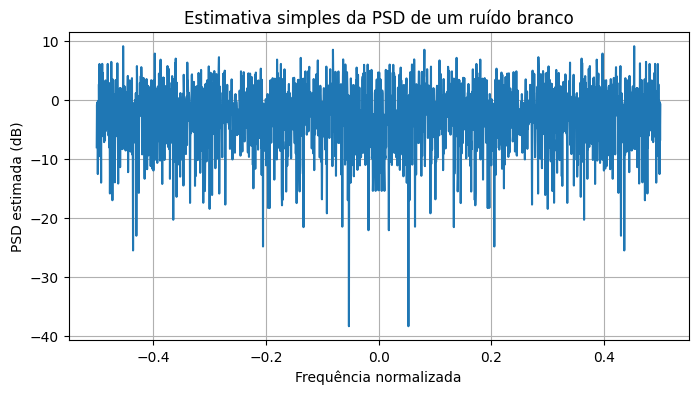

In [14]:
np.random.seed(10)
N = 2048
x = np.random.normal(0, 1, N)

X = np.fft.fftshift(np.fft.fft(x))
psd = (np.abs(X)**2) / N
f = np.fft.fftshift(np.fft.fftfreq(N, d=1.0))

plt.figure(figsize=(8,4))
plt.plot(f, 10*np.log10(psd + 1e-12))
plt.title('Estimativa simples da PSD de um ruído branco')
plt.xlabel('Frequência normalizada')
plt.ylabel('PSD estimada (dB)')
plt.grid(True)
plt.show()

### Observação
Na prática, a PSD estimada apresenta flutuações devido ao número finito de amostras. Ainda assim, o comportamento geral é aproximadamente plano, como esperado para ruído branco.

## Exercícios:

1. Defina experimento aleatório, evento e espaço amostral com exemplos em comunicações.
2. Explique a diferença entre pdf, pmf e cdf.
3. Calcule média e variância de uma variável aleatória discreta dada sua distribuição.
4. Explique o significado físico da autocorrelação.
5. Diferencie processo estacionário e ergódico.
6. Justifique por que o ruído térmico é frequentemente modelado como gaussiano.
7. Explique o que significa a PSD de um ruído branco.
8. Relacione sinais aleatórios com a análise de probabilidade de erro em sistemas digitais.

## 17. Referências introdutórias

- HAYKIN, Simon. *Communication Systems*.
- PROAKIS, John G.; SALEHI, Masoud. *Fundamentals of Communication Systems*.
- LATHI, B. P.; DING, Zhi. *Modern Digital and Analog Communication Systems*.
- PAPOULIS, Athanasios; PILLAI, S. Unnikrishna. *Probability, Random Variables, and Stochastic Processes*.